# Name: Morium Tanny
# ID:20251711
# WMASDS 04: Introduction to Data Science With Python (Section A)
# Summer 2025
## 

##  Loading the Dataset

In [9]:
import numpy as np                 # Numerical operations, arrays, and mathematical functions
import pandas as pd                # Data manipulation and analysis (DataFrames, CSV/Excel I/O)
import scipy as sp                 # Various algorithm for Linear algebra, diff equ. and statistics etc.
import matplotlib as mpl           # visualization for bar/scatter/histogram 
import matplotlib.pyplot as plt    # Basic plotting and data visualization
import seaborn as sns              # Advanced statistical data visualization (heatmaps, pairplots)
import scipy.stats                 # Statistical functions and probability distributions

from sklearn.preprocessing import MinMaxScaler        # scales data to a 0–1 range.
from sklearn.model_selection import train_test_split  # Split data into training and testing sets
from sklearn.linear_model import LinearRegression     # Linear regression modeling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # Metrics to evaluate regression model performance

import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [10]:
import pandas as pd

print("The Dataset:")
df = pd.read_csv("D:\Assignment Data\global_supply_chain_disruption_v1.csv")
df

The Dataset:


,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken
0,ORD-00BCB25B,4/5/2024,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Textiles,18,21,18,0,On Time,NaN,0.81,8.9,1.83,1611.81,1781,Standard Shipping
1,ORD-EBDBACB7,9/8/2024,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Pharmaceuticals,2,5,2,0,On Time,NaN,0.70,5.9,2.44,76127.70,8142,Standard Shipping
2,ORD-4052DA06,1/28/2025,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Semiconductors,3,4,4,0,On Time,NaN,0.46,8.1,3.86,13699.18,1706,Standard Shipping
3,ORD-03F41ABB,2/4/2025,"Santos, BR","Shanghai, CN",Commodity,Sea,Consumer Electronics,35,36,35,0,On Time,NaN,0.88,9.3,1.58,5448.24,5796,Standard Shipping
4,ORD-347A88A6,5/20/2025,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,On Time,NaN,0.55,2.9,3.12,1215.98,1569,Standard Shipping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ORD-525E3FA5,10/14/2024,"Tokyo, JP","Singapore, SG",Intra-Asia,Sea,Consumer Electronics,7,8,8,0,On Time,NaN,0.58,8.1,3.38,7346.21,9299,Standard Shipping
9996,ORD-5E9DBD46,9/10/2024,"Tokyo, JP","Singapore, SG",Intra-Asia,Sea,Textiles,7,10,7,0,On Time,NaN,0.37,5.5,2.34,4112.06,6003,Standard Shipping
9997,ORD-E6949429,7/13/2024,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,On Time,NaN,0.84,1.0,4.56,7346.20,7985,Standard Shipping
9998,ORD-29B9A2DA,7/21/2024,"Mumbai, IN","Felixstowe, UK",Suez,Sea,Semiconductors,24,27,25,0,On Time,NaN,0.53,4.7,1.05,5810.94,7596,Standard Shipping


In [11]:
print("DataFrame Information:")
print(df.info())

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  10000 non-null  object 
 1   Order_Date                10000 non-null  object 
 2   Origin_City               10000 non-null  object 
 3   Destination_City          10000 non-null  object 
 4   Route_Type                10000 non-null  object 
 5   Transportation_Mode       10000 non-null  object 
 6   Product_Category          10000 non-null  object 
 7   Base_Lead_Time_Days       10000 non-null  int64  
 8   Scheduled_Lead_Time_Days  10000 non-null  int64  
 9   Actual_Lead_Time_Days     10000 non-null  int64  
 10  Delay_Days                10000 non-null  int64  
 11  Delivery_Status           10000 non-null  object 
 12  Disruption_Event          1267 non-null   object 
 13  Geopolitical_Risk_Index   10000 non-nul

In [12]:
print("Summary Statistics:")
df.describe()

Summary Statistics:


,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,17.509900,19.50320,18.704300,0.947500,0.496770,4.976460,3.516010,11437.916337,5033.732500
std,10.902843,10.93356,11.662815,3.117293,0.230611,2.879658,1.209597,21086.689659,2830.996788
min,2.000000,3.00000,1.000000,0.000000,0.100000,0.000000,-1.150000,59.940000,101.000000
25%,7.000000,9.00000,7.000000,0.000000,0.300000,2.500000,2.700000,2308.387500,2590.500000
50%,18.000000,20.00000,18.000000,0.000000,0.500000,4.900000,3.500000,4520.170000,5044.500000
75%,28.000000,29.00000,28.000000,0.000000,0.690000,7.500000,4.350000,7055.107500,7493.000000
max,35.000000,38.00000,49.000000,20.000000,0.900000,10.000000,7.920000,206814.290000,9999.000000


## Data Preprocessing (Cleaning)

In [13]:
print("Checking Missing Values:")
df.isnull().sum()

Checking Missing Values:


Order_ID                       0
Order_Date                     0
Origin_City                    0
Destination_City               0
Route_Type                     0
Transportation_Mode            0
Product_Category               0
Base_Lead_Time_Days            0
Scheduled_Lead_Time_Days       0
Actual_Lead_Time_Days          0
Delay_Days                     0
Delivery_Status                0
Disruption_Event            8733
Geopolitical_Risk_Index        0
Weather_Severity_Index         0
Inflation_Rate_Pct             0
Shipping_Cost_USD              0
Order_Weight_Kg                0
Mitigation_Action_Taken        0
dtype: int64

In [14]:
#dropping missing values
df = df.dropna()

In [7]:
#Checking Duplicates
df.duplicated().sum()

np.int64(0)

In [15]:
#Dropping Duplicates
df = df.drop_duplicates()

##  Exploratory Data Analysis (EDA)

In [27]:
#Calculate Skewness
skew_value = df['Delay_Days'].skew()
print("Skewness of Delay_Days Column:", skew_value)
print(f"Skewness of Delay_Days column: {skew_value:.2f}")  
#f"..." → makes it an f-string, allowing {} to hold variables.

Skewness of Delay_Days Column: 0.570869298513541
Skewness of Delay_Days column: 0.57


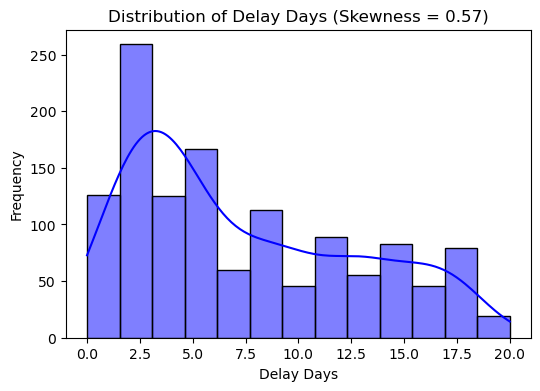

In [10]:
# Plot distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['Delay_Days'], kde=True, color='blue')
plt.title(f"Distribution of Delay Days (Skewness = {skew_value:.2f})")
plt.xlabel('Delay Days')
plt.ylabel('Frequency')
plt.show()

In [12]:
# Calculating kurtosis
kurt_value = df['Delay_Days'].kurt()
print("Kurtosis of Delay Days:", kurt_value)
print(f"Kurtosis of Delay Days column: {kurt_value:.2f}")  


Kurtosis of Delay Days: -0.8713227497266254
Kurtosis of Delay Days column: -0.87


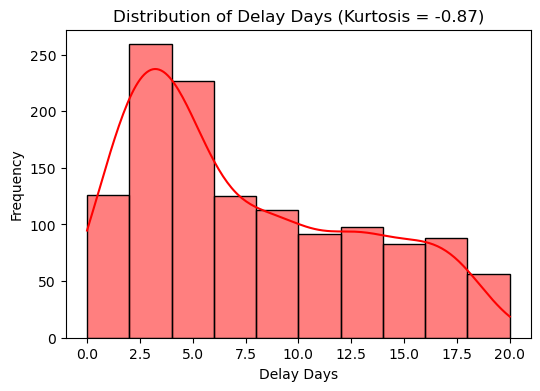

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(df['Delay_Days'], kde=True, color='red', bins=10)
plt.title(f"Distribution of Delay Days (Kurtosis = {kurt_value:.2f})")
plt.xlabel('Delay Days')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='Transportation_Mode', ylabel='Delay_Days'>

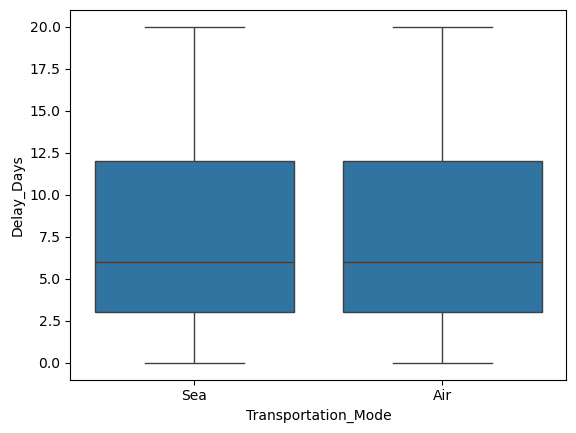

In [14]:
import seaborn as sns

sns.boxplot(x="Transportation_Mode", y="Delay_Days", data=df)

([0, 1, 2],
 [Text(0, 0, 'Port Congestion'),
  Text(1, 0, 'Geopolitical Conflict (Route Diversion)'),
  Text(2, 0, 'Severe Weather (Typhoon/Storm)')])

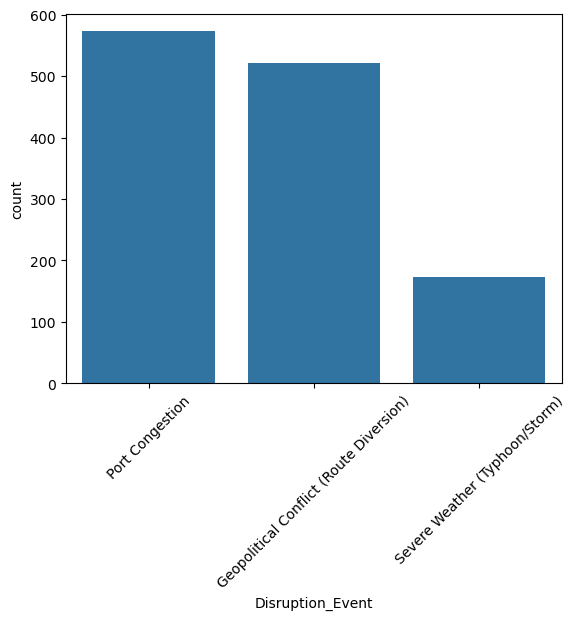

In [18]:
sns.countplot(x="Disruption_Event", data=df)
plt.xticks(rotation=45)

## Hypothesis Testing

In [26]:
import pandas as pd
from scipy import stats

# Grouping delay days by weather severity levels
groups = df.groupby('Weather_Severity_Index')['Delay_Days'].apply(list)

# Perform one-way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA Results (Weather Severity vs Delay Days)")
print("F-statistic:", f_stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject H0: Weather severity significantly affects delay.")
else:
    print("Fail to reject H0: No significant effect of weather severity.")

ANOVA Results (Weather Severity vs Delay Days)
F-statistic: 1.1792396189517804
p-value: 0.11789984703736171
Fail to reject H0: No significant effect of weather severity.


In [27]:
import pandas as pd
from scipy import stats

# Grouping delay days by weather severity levels
groups = df.groupby('Geopolitical_Risk_Index')['Delay_Days'].apply(list)

# Perform one-way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA Results (Geopolitical Risk vs Delay Days)")
print("F-statistic:", f_stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject H0: geopolitical risk significantly affects delay.")
else:
    print("Fail to reject H0: No significant effect of geopolitical risk.")

ANOVA Results (Geopolitical Risk vs Delay Days)
F-statistic: 0.7631479455345377
p-value: 0.9385103137396242
Fail to reject H0: No significant effect of geopolitical risk.


##  Correlation

In [28]:
df_corr = df.select_dtypes(include=['number']).corr().round(2)

print(df_corr)

                          Base_Lead_Time_Days  Scheduled_Lead_Time_Days  \
Base_Lead_Time_Days                      1.00                      1.00   
Scheduled_Lead_Time_Days                 1.00                      1.00   
Actual_Lead_Time_Days                    0.92                      0.92   
Delay_Days                               0.28                      0.27   
Geopolitical_Risk_Index                 -0.02                     -0.02   
Weather_Severity_Index                  -0.00                      0.00   
Inflation_Rate_Pct                       0.05                      0.05   
Shipping_Cost_USD                       -0.50                     -0.50   
Order_Weight_Kg                          0.00                     -0.00   

                          Actual_Lead_Time_Days  Delay_Days  \
Base_Lead_Time_Days                        0.92        0.28   
Scheduled_Lead_Time_Days                   0.92        0.27   
Actual_Lead_Time_Days                      1.00        0.63 

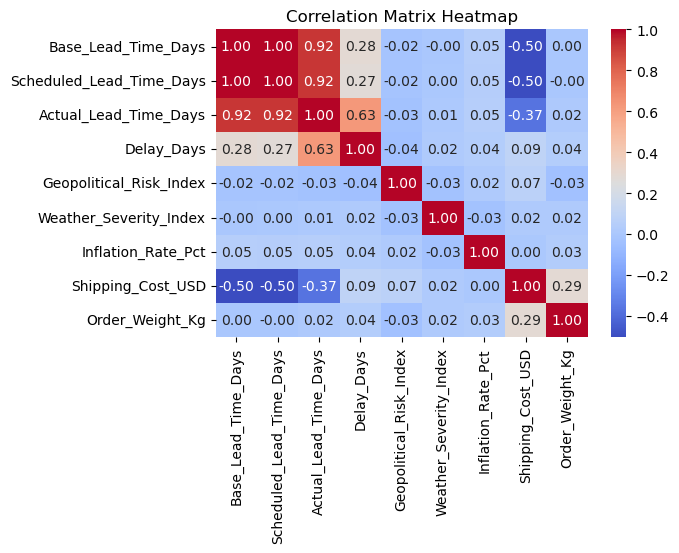

Shipping_Cost_USD           1.000000
Order_Weight_Kg             0.286911
Delay_Days                  0.090469
Geopolitical_Risk_Index     0.071385
Weather_Severity_Index      0.023296
Inflation_Rate_Pct          0.004972
Actual_Lead_Time_Days      -0.367754
Scheduled_Lead_Time_Days   -0.501249
Base_Lead_Time_Days        -0.504887
Name: Shipping_Cost_USD, dtype: float64


In [29]:
numeric_df = df.select_dtypes(include=['number'])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Visualize the correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()

# Display specific correlations with the target (Shipping Cost)
print(corr_matrix['Shipping_Cost_USD'].sort_values(ascending=False))

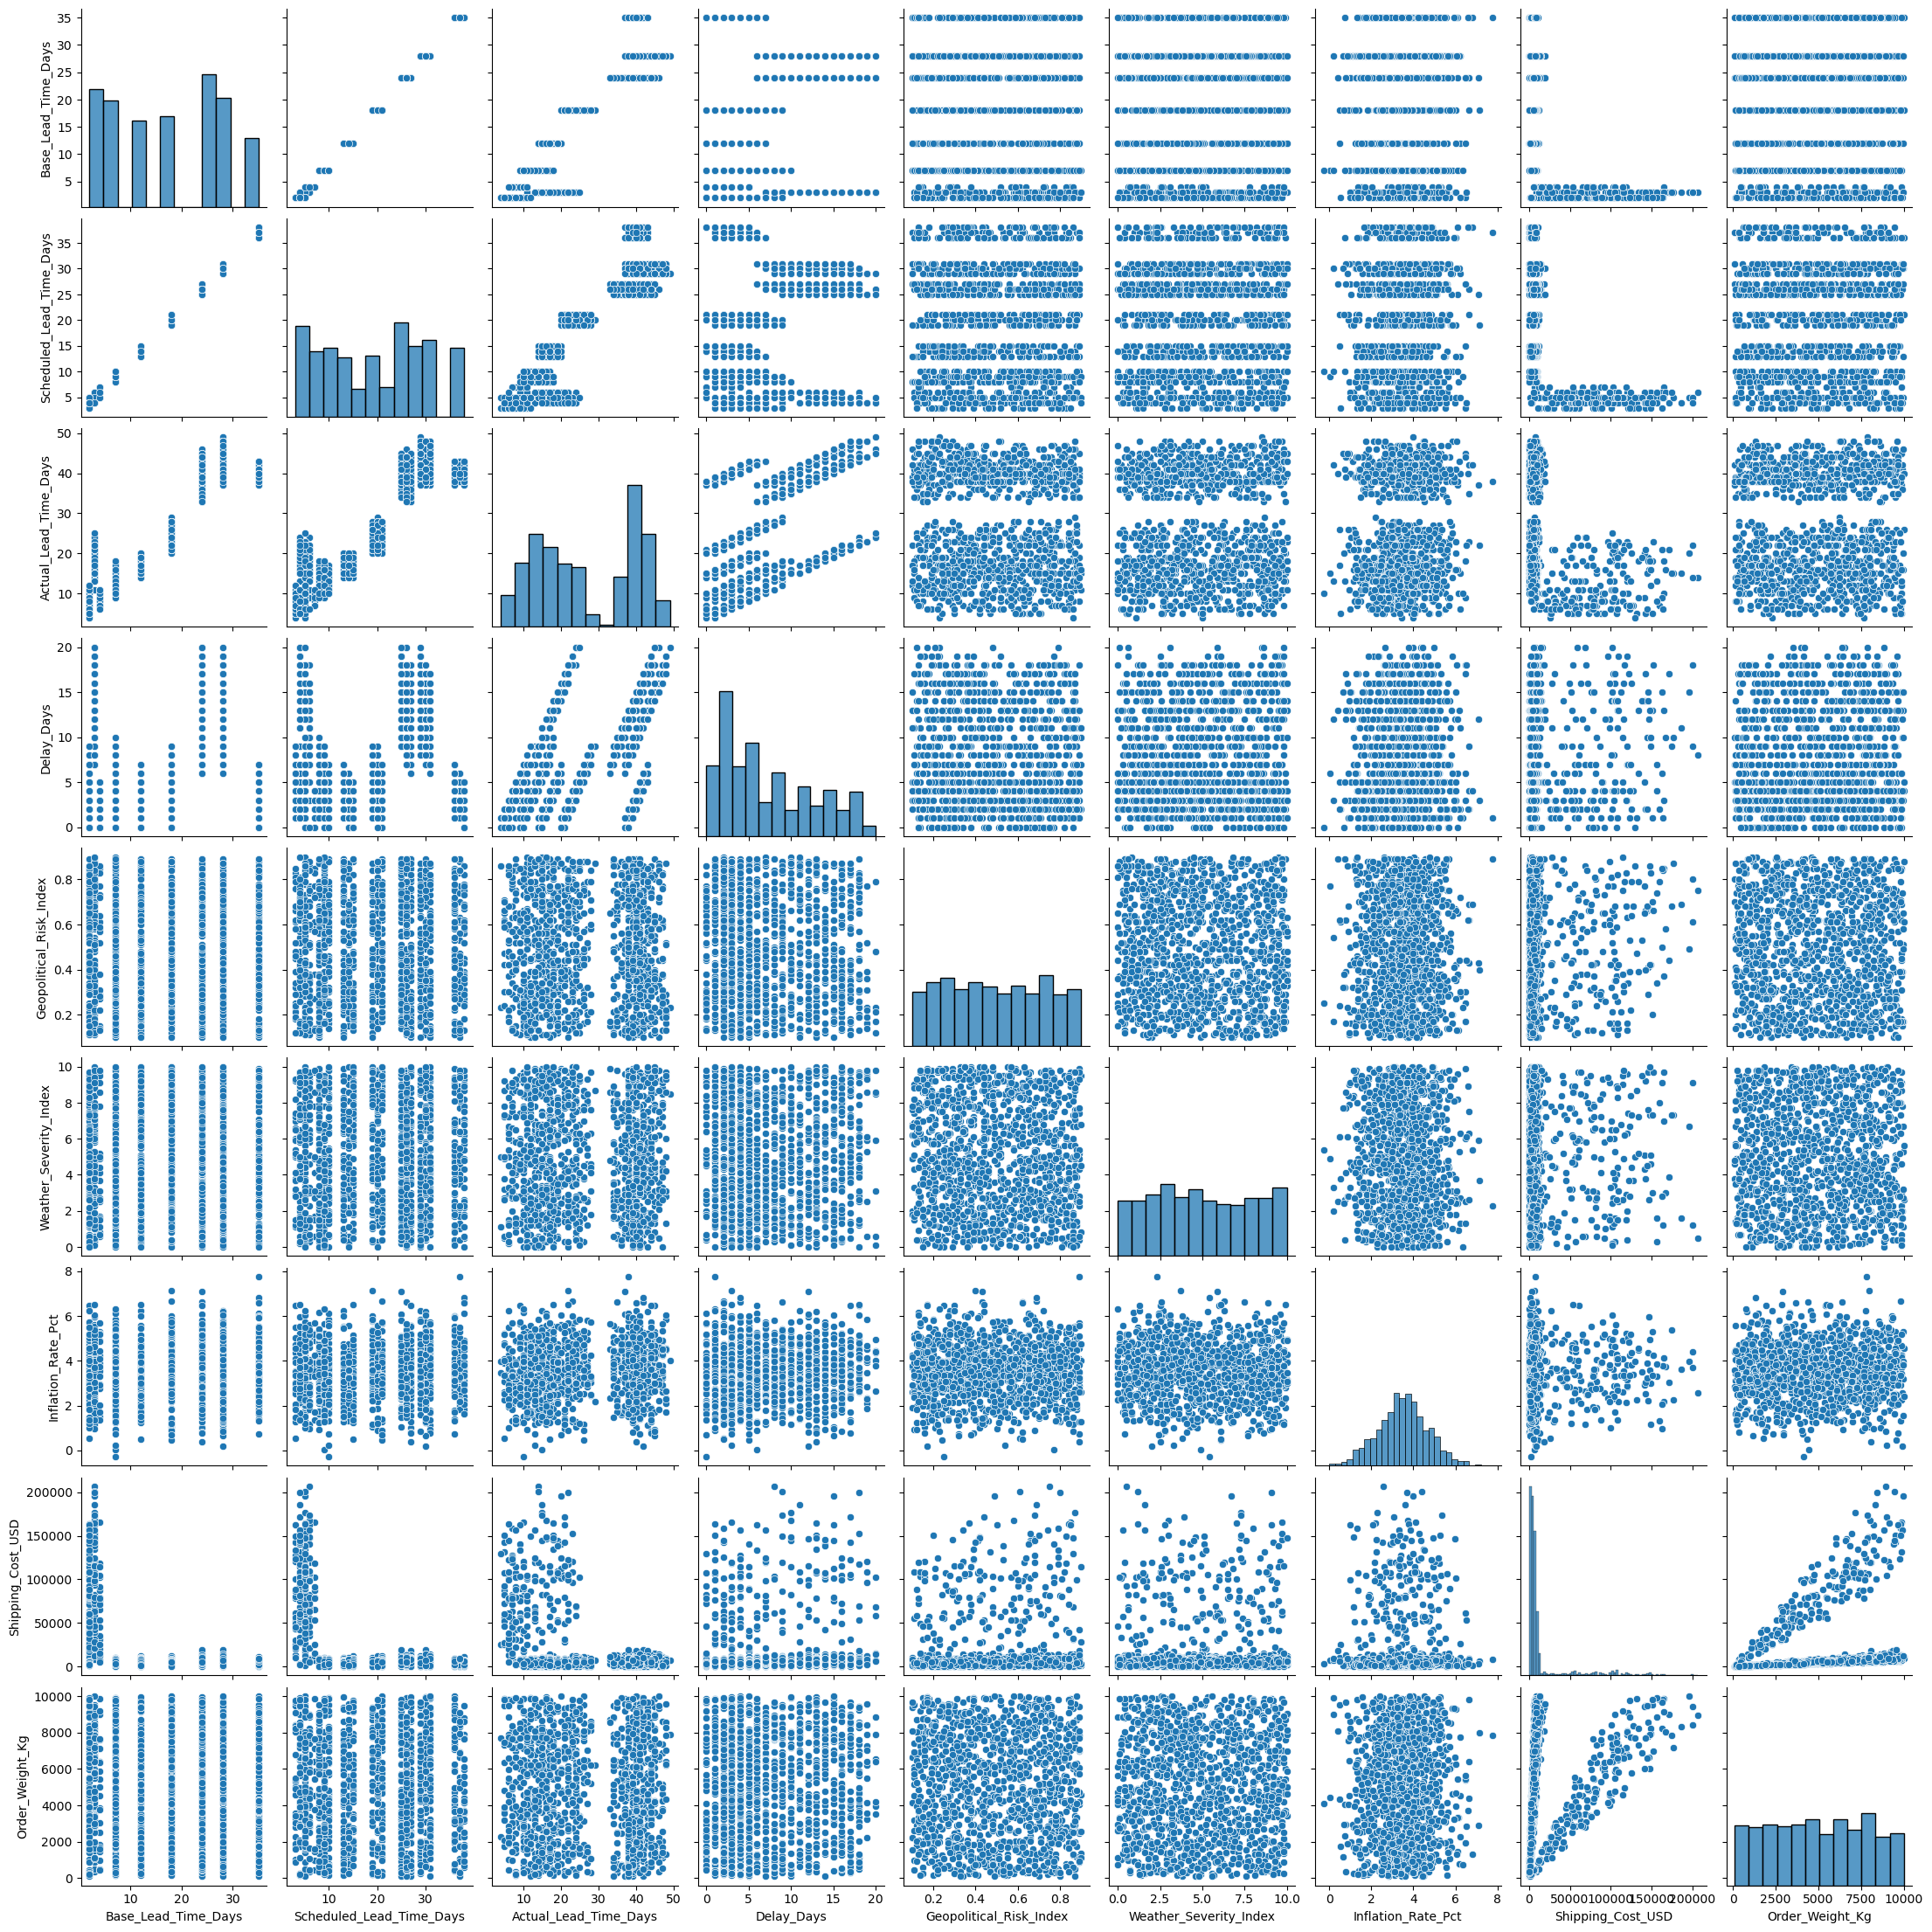

In [30]:
sns.pairplot(df)
plt.show()

## Multiple Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Preparing Features and Target
X = df[['Geopolitical_Risk_Index', 'Weather_Severity_Index', 'Inflation_Rate_Pct', 'Order_Weight_Kg']]
y_reg = df['Delay_Days']

# 2. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# 3. Predict
y_pred = mlr_model.predict(X_test)

In [24]:
# Model Evaluation

# Mean squared error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# r squared
r2 = r2_score(y_test, y_pred)

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Print the results
print("Model Evaluation Metrics:\n")
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)
print(f'Mean Absolute Error: {mae:.2f}')


Model Evaluation Metrics:

Mean Squared Error: 30.12361179368493
Root Mean Squared Error: 5.48849813643814
R2 Score: -0.02721125813774039
Mean Absolute Error: 4.71


In [25]:
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor 

X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

print("\nVariance Inflation Factors (VIF):\n", vif_data)


Variance Inflation Factors (VIF):
                    Feature        VIF
0                    const  20.516409
1  Geopolitical_Risk_Index   1.002460
2   Weather_Severity_Index   1.002066
3       Inflation_Rate_Pct   1.002513
4          Order_Weight_Kg   1.002680


## Logistic Regression

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

In [17]:
# 1. Handling missing values
df['Disruption_Event'] = df['Disruption_Event'].fillna('None')

# 2. Drop identifiers and potential leakage columns
# Including Delay_Days or Actual_Lead_Time would make the model "cheat"
cols_to_drop = ['Order_ID', 'Order_Date', 'Origin_City', 'Destination_City', 
                'Delay_Days', 'Actual_Lead_Time_Days']
df_clean = df.drop(columns=cols_to_drop)

# 3. Encoding
df_clean['Delivery_Status'] = df_clean['Delivery_Status'].map({'Late': 1, 'On Time': 0})

categorical_cols = ['Route_Type', 'Transportation_Mode', 'Product_Category', 
                    'Disruption_Event', 'Mitigation_Action_Taken']
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# 4. Define Features and Target
X = df_encoded.drop('Delivery_Status', axis=1)
y = df_encoded['Delivery_Status']

In [18]:
# 5. Train-Test Split and Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Build and Fit Model with Class Balancing
# Added class_weight='balanced' to handle the 244 vs 10 split
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
y_pred = model.predict(X_test_scaled)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.7440944881889764

Confusion Matrix:
 [[  8   2]
 [ 63 181]]

Classification Report:
               precision    recall  f1-score   support

           0       0.11      0.80      0.20        10
           1       0.99      0.74      0.85       244

    accuracy                           0.74       254
   macro avg       0.55      0.77      0.52       254
weighted avg       0.95      0.74      0.82       254



In [20]:
coefficients = model.coef_
intercept = model.intercept_
print("Coefficients:", coefficients)
print("Intercept:", intercept)

Coefficients: [[ 5.04180246 -4.83408908  0.04588494  0.18583833 -0.02672823  0.02444218
   0.19579975 -0.16537921 -0.19607625  0.21879174  1.14580835 -0.22450402
   0.10348935  0.25319109 -0.22898044 -0.08192701 -0.24552082  0.11689997
  -1.77075612  0.92955617  0.41570269 -0.04375727]]
Intercept: [3.17354224]


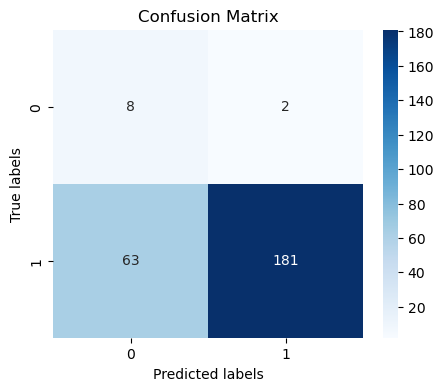

In [21]:
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=True, annot_kws={"fontsize":10})
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [22]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance:\n", feature_importance)


Feature Importance:
                                             Feature  Coefficient
0                               Base_Lead_Time_Days     5.041802
10                                  Route_Type_Suez     1.145808
19  Disruption_Event_Severe Weather (Typhoon/Storm)     0.929556
20               Mitigation_Action_Taken_Re-routing     0.415703
13                Product_Category_Perishable Foods     0.253191
9                                Route_Type_Pacific     0.218792
6                                   Order_Weight_Kg     0.195800
3                            Weather_Severity_Index     0.185838
17                        Product_Category_Textiles     0.116900
12            Product_Category_Consumer Electronics     0.103489
2                           Geopolitical_Risk_Index     0.045885
5                                 Shipping_Cost_USD     0.024442
4                                Inflation_Rate_Pct    -0.026728
21        Mitigation_Action_Taken_Standard Shipping    -0.043757
15 

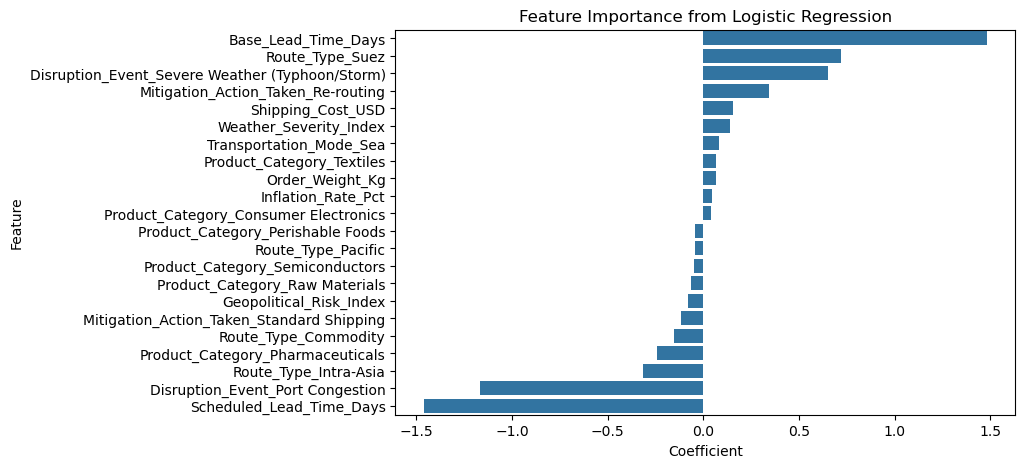

In [60]:
plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title("Feature Importance from Logistic Regression")
plt.show()

## Implementing the SMOTE 

Accuracy Score: 0.7795

Confusion Matrix:
 [[  7   3]
 [ 53 191]]

Classification Report:
               precision    recall  f1-score   support

           0       0.12      0.70      0.20        10
           1       0.98      0.78      0.87       244

    accuracy                           0.78       254
   macro avg       0.55      0.74      0.54       254
weighted avg       0.95      0.78      0.85       254



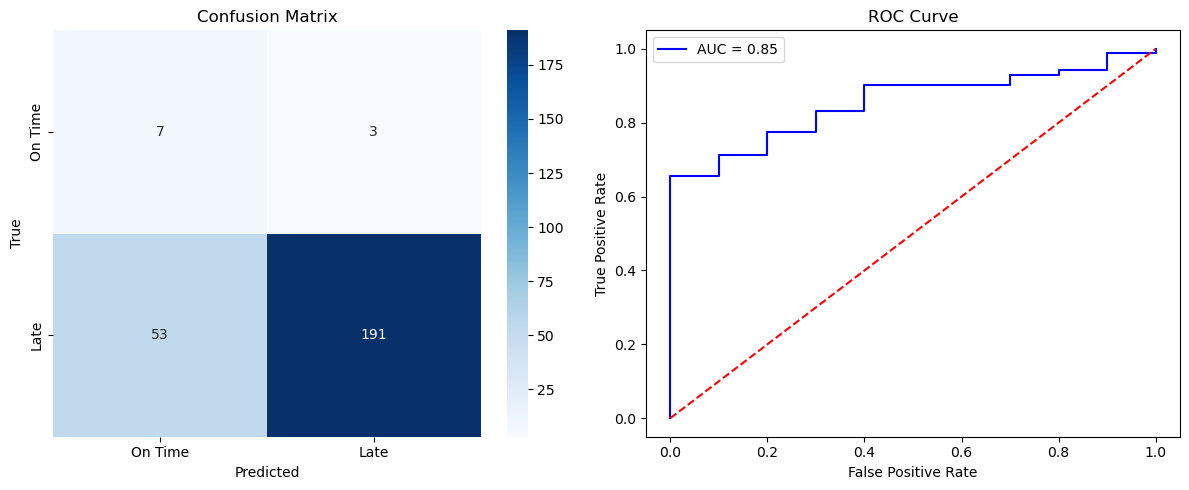


Top Predictors for Lateness:
                                             Feature  Coefficient
0                               Base_Lead_Time_Days     7.838206
10                                  Route_Type_Suez     1.278922
19  Disruption_Event_Severe Weather (Typhoon/Storm)     0.988237
20               Mitigation_Action_Taken_Re-routing     0.433222
13                Product_Category_Perishable Foods     0.407775


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE

# 1. DATA CLEANING & PREPROCESSING
df['Disruption_Event'] = df['Disruption_Event'].fillna('None')

# Drop identifiers and leakage columns (to ensure the model doesn't "cheat")
cols_to_drop = ['Order_ID', 'Order_Date', 'Origin_City', 'Destination_City', 
                'Delay_Days', 'Actual_Lead_Time_Days']
df_clean = df.drop(columns=cols_to_drop)

# Encode Target: Late = 1, On Time = 0
df_clean['Delivery_Status'] = df_clean['Delivery_Status'].map({'Late': 1, 'On Time': 0})

# One-Hot Encoding for categorical features
categorical_cols = ['Route_Type', 'Transportation_Mode', 'Product_Category', 
                    'Disruption_Event', 'Mitigation_Action_Taken']
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# 2. FEATURE & TARGET DEFINITION
X = df_encoded.drop('Delivery_Status', axis=1)
y = df_encoded['Delivery_Status']

# 3. TRAIN-TEST SPLIT & SCALING
# stratify=y keeps the 10 "On Time" cases distributed properly between sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use transform (not fit_transform) for test set

# 4. ADDRESSING IMBALANCE WITH SMOTE
# Since the minority class is very small, we use a low k_neighbors
sm = SMOTE(random_state=42, k_neighbors=2)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

# 5. MODEL TRAINING
model = LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)

# 6. EVALUATION
y_pred = model.predict(X_test_scaled)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. VISUALIZATIONS
plt.figure(figsize=(12, 5))

# Plot 1: Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Late'], yticklabels=['On Time', 'Late'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# 8. FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nTop Predictors for Lateness:\n", feature_importance.head())

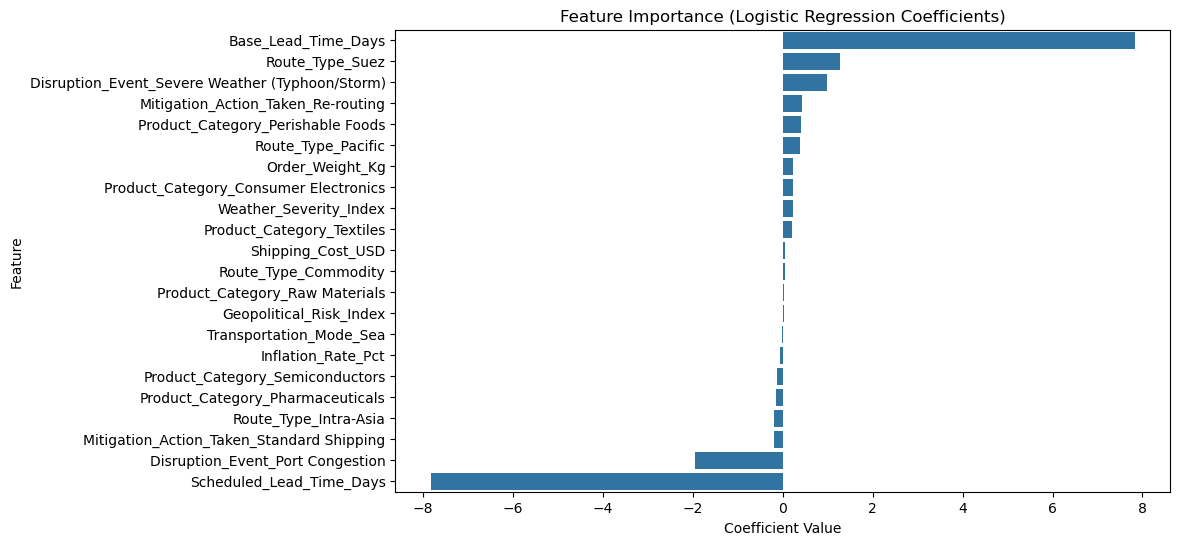

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()